<a href="https://colab.research.google.com/github/Rupasunkara125/Projects/blob/main/Road_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv(r"/content/RTA Dataset.csv")

In [ ]:
data

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


In [ ]:
data.shape

(12316, 32)

In [ ]:
columns= [
    'Casualty_class', 'Sex_of_casualty',
    'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality',
    'Pedestrian_movement', 'Service_year_of_vehicle'
]
data = data.drop(columns=columns)

In [ ]:
  data.shape

(12316, 25)

In [ ]:
data['Hour'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.hour
data.drop('Time', axis=1, inplace=True)

In [ ]:
data = data.drop_duplicates()
cat_cols = data.select_dtypes(include='object').columns
num_cols = data.select_dtypes(exclude='object').columns
data[cat_cols] = data[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))
data[num_cols] = data[num_cols].apply(lambda x: x.fillna(x.median()))

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data['Accident_severity'] = encoder.fit_transform(data['Accident_severity'])

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinals = [
'Age_band_of_driver',
'Driving_experience',
'Educational_level',
'Age_band_of_casualty',
'Day_of_week'
]
encoder1 = OrdinalEncoder()
for col in ordinals:
    data[col] = data[col].astype(str)
    data[col] = encoder1.fit_transform(data[[col]])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

onehot = [
'Sex_of_driver','Vehicle_driver_relation','Type_of_vehicle',
'Owner_of_vehicle','Defect_of_vehicle','Area_accident_occured',
'Lanes_or_Medians','Road_allignment','Types_of_Junction',
'Road_surface_type','Road_surface_conditions','Light_conditions',
'Weather_conditions','Type_of_collision','Vehicle_movement',
'Cause_of_accident'
]
encoder2 = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
for col in onehot:
    data[col] = data[col].astype(str)
encoded = encoder2.fit_transform(data[onehot])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder2.get_feature_names_out(onehot)
)
data = pd.concat([data.drop(columns=onehot), encoded_df], axis=1)

In [ ]:
x = data.drop('Accident_severity', axis=1)
y = data['Accident_severity']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23, stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
Random=RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=23
)
Random.fit(x_train,y_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=200,
                       random_state=23)

In [ ]:
predict=Random.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict)

0.8469967532467533

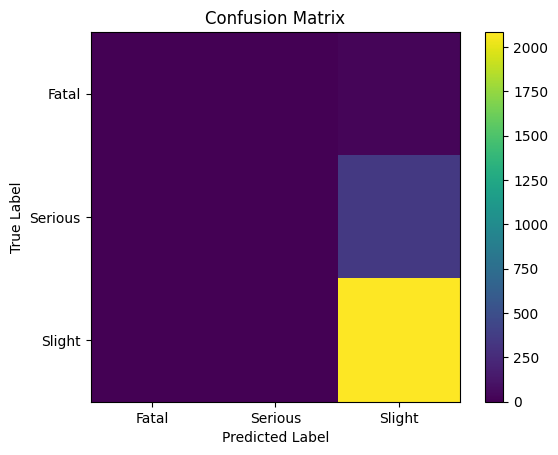

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(3), ['Fatal','Serious','Slight'])
plt.yticks(np.arange(3), ['Fatal','Serious','Slight'])

plt.colorbar()
plt.show()

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    random_state=23
)
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
predict1=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict1)

0.8478084415584416

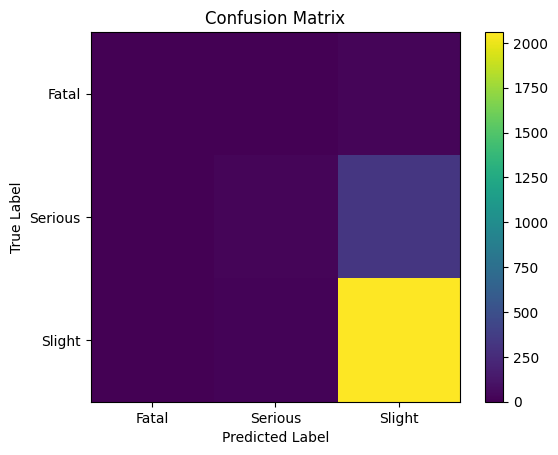

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict1)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(3), ['Fatal','Serious','Slight'])
plt.yticks(np.arange(3), ['Fatal','Serious','Slight'])

plt.colorbar()
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
Gradient=GradientBoostingClassifier()
Gradient.fit(x_train,y_train)

GradientBoostingClassifier()

In [ ]:
predict2=Gradient.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict2)

0.8474025974025974

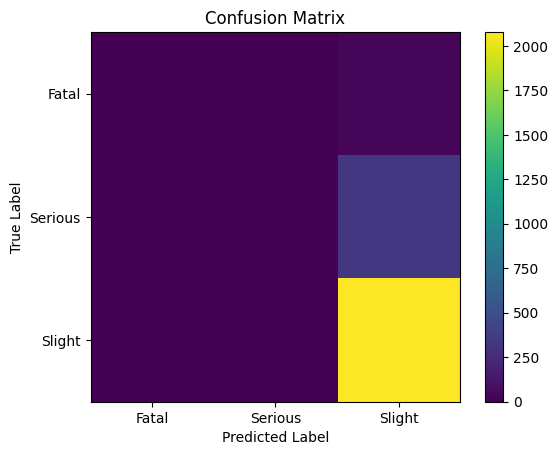

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict2)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(3), ['Fatal','Serious','Slight'])
plt.yticks(np.arange(3), ['Fatal','Serious','Slight'])

plt.colorbar()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
Decision=DecisionTreeClassifier()
Decision.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
predict3=Decision.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict3)

0.7731331168831169

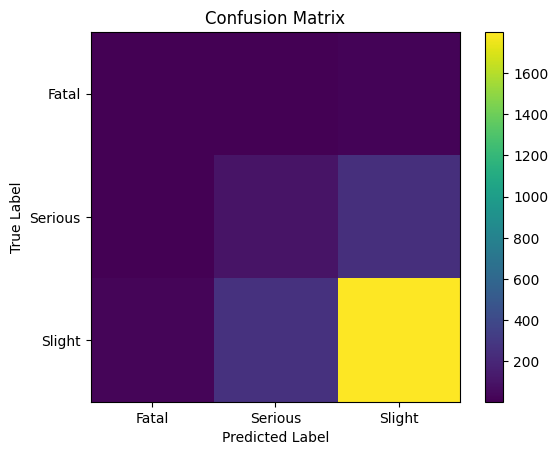

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict3)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(3), ['Fatal','Serious','Slight'])
plt.yticks(np.arange(3), ['Fatal','Serious','Slight'])

plt.colorbar()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
Logistic=LogisticRegression()
Logistic.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
predict4=Logistic.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predict4)

0.846185064935065

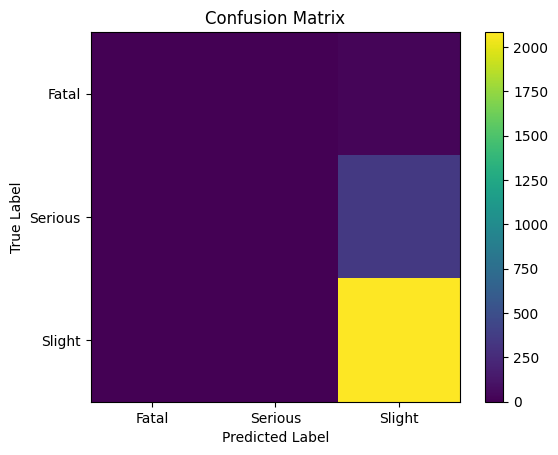

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_test, predict4)
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(3), ['Fatal','Serious','Slight'])
plt.yticks(np.arange(3), ['Fatal','Serious','Slight'])

plt.colorbar()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

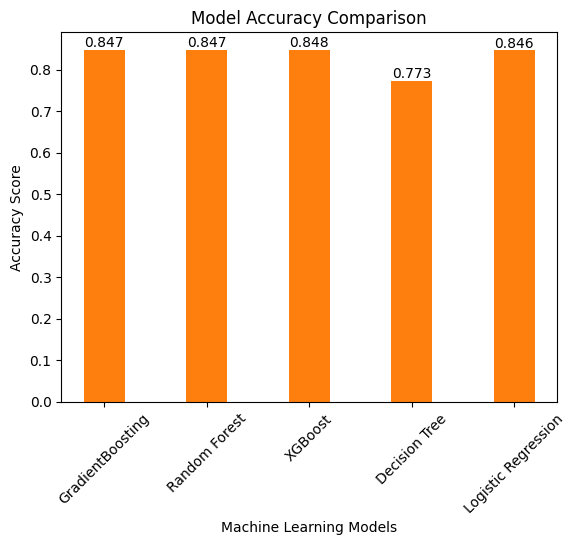

In [ ]:
import matplotlib.pyplot as plt

models = [
    "GradientBoosting",
    "Random Forest",
    "XGBoost",
    "Decision Tree",
    "Logistic Regression"
]
scores = [
    0.8474025974025974,
    0.8469967532467533,
    0.8478084415584416,
    0.7731331168831169,
    0.846185064935065
]
plt.figure()
plt.bar(models, scores, width=0.4)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=45)
bars = plt.bar(models, scores, width=0.4)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y,3),
             ha='center', va='bottom')
plt.show()
plt.show()